<a href="https://colab.research.google.com/github/SrishanthGorla/SERAI/blob/main/Measure_poisoning_impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
# Cell 2: Load Dataset

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(iris.target, name="target")

print("Dataset shape:", X.shape)
print("\nFirst 5 records:")
display(X.head())

print("\nClass distribution:")
print(y.value_counts())

Dataset shape: (150, 4)

First 5 records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [3]:
# Cell 3: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 105
Testing samples: 45


In [4]:
# Cell 4: Train Clean Model

clean_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clean_model.fit(X_train, y_train)

clean_predictions = clean_model.predict(X_test)

clean_accuracy = accuracy_score(y_test, clean_predictions)
clean_f1 = f1_score(
    y_test,
    clean_predictions,
    average="weighted"
)

print("Clean Model Performance")
print("-----------------------")
print(f"Accuracy : {clean_accuracy:.4f}")
print(f"F1-score : {clean_f1:.4f}")

Clean Model Performance
-----------------------
Accuracy : 0.8889
F1-score : 0.8878


In [5]:
# Cell 5: Controlled Data Poisoning

def create_poisoned_data(X_original, y_original, contamination, random_state=42):
    """
    Create a controlled poisoned dataset.

    contamination:
        Fraction of training records to poison.
    """

    X_poisoned = X_original.copy().reset_index(drop=True)
    y_poisoned = y_original.copy().reset_index(drop=True)

    rng = np.random.RandomState(random_state)

    n_samples = len(X_poisoned)

    # Number of records to poison
    n_poison = int(n_samples * contamination)

    # Randomly select records
    poison_indices = rng.choice(
        n_samples,
        size=n_poison,
        replace=False
    )

    for idx in poison_indices:

        # Select a random feature
        feature_idx = rng.randint(X_poisoned.shape[1])

        # Add controlled feature perturbation
        X_poisoned.iloc[idx, feature_idx] *= 1.30

        # Change the class label
        current_label = y_poisoned.iloc[idx]

        possible_labels = [
            label for label in sorted(y_original.unique())
            if label != current_label
        ]

        y_poisoned.iloc[idx] = rng.choice(possible_labels)

    return X_poisoned, y_poisoned, poison_indices

In [6]:
# Cell 6: Run Experiment for Different Contamination Levels

contamination_levels = [0.00, 0.05, 0.10, 0.15]

results = []

poisoned_datasets = {}

for level in contamination_levels:

    X_p, y_p, poison_indices = create_poisoned_data(
        X_train,
        y_train,
        contamination=level,
        random_state=42
    )

    # Train model
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_p, y_p)

    # Evaluate on CLEAN test data
    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    # Store results
    results.append({
        "Contamination": level * 100,
        "Poisoned Records": len(poison_indices),
        "Accuracy": accuracy,
        "F1 Score": f1
    })

    poisoned_datasets[level] = {
        "X": X_p,
        "y": y_p,
        "poison_indices": poison_indices
    }

results_df = pd.DataFrame(results)

display(results_df)

,Contamination,Poisoned Records,Accuracy,F1 Score
0,0.0,0,0.888889,0.887767
1,5.0,5,0.888889,0.885852
2,10.0,10,0.911111,0.909370
3,15.0,15,0.911111,0.909370


In [7]:
# Cell 7: Calculate Poisoning Impact

results_df["Accuracy Change"] = (
    results_df["Accuracy"] - clean_accuracy
)

results_df["F1 Change"] = (
    results_df["F1 Score"] - clean_f1
)

results_df["Accuracy Drop (%)"] = (
    (clean_accuracy - results_df["Accuracy"])
    * 100
)

results_df["F1 Drop (%)"] = (
    (clean_f1 - results_df["F1 Score"])
    * 100
)

display(results_df)

,Contamination,Poisoned Records,Accuracy,F1 Score,Accuracy Change,F1 Change,Accuracy Drop (%),F1 Drop (%)
0,0.0,0,0.888889,0.887767,0.000000,0.000000,0.000000,0.000000
1,5.0,5,0.888889,0.885852,0.000000,-0.001914,0.000000,0.191430
2,10.0,10,0.911111,0.909370,0.022222,0.021604,-2.222222,-2.160365
3,15.0,15,0.911111,0.909370,0.022222,0.021604,-2.222222,-2.160365


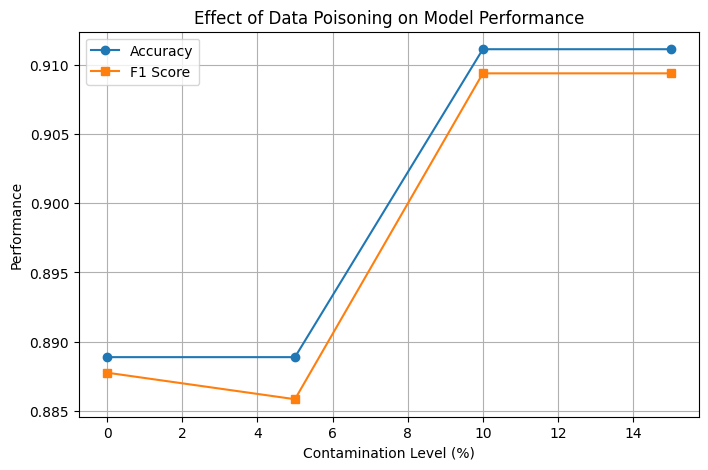

In [8]:
# Cell 8: Contamination vs Model Performance

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Contamination"],
    results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    results_df["Contamination"],
    results_df["F1 Score"],
    marker="s",
    label="F1 Score"
)

plt.xlabel("Contamination Level (%)")
plt.ylabel("Performance")
plt.title("Effect of Data Poisoning on Model Performance")

plt.grid(True)
plt.legend()

plt.show()

In [9]:
# Cell 9: Anomaly Detection

def detect_anomalies(X_data, contamination):

    # If there are no poisoned records
    if contamination == 0:
        return np.array([], dtype=int)

    detector = IsolationForest(
        contamination=contamination,
        random_state=42
    )

    predictions = detector.fit_predict(X_data)

    # Isolation Forest:
    # -1 = anomaly
    #  1 = normal

    suspicious_indices = np.where(predictions == -1)[0]

    return suspicious_indices

In [10]:
# Cell 10: Label Consistency Detection

def detect_label_anomalies(X_data, y_data):

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X_data)

    knn = KNeighborsClassifier(n_neighbors=5)

    knn.fit(X_scaled, y_data)

    predicted_labels = knn.predict(X_scaled)

    suspicious = np.where(
        predicted_labels != y_data
    )[0]

    return suspicious

In [11]:
# Cell 11: Compare Known Poisoned Records with Detected Records

detection_results = []

for level in contamination_levels:

    data = poisoned_datasets[level]

    X_p = data["X"]
    y_p = data["y"]

    known_poison = set(data["poison_indices"])

    # Feature anomaly detection
    feature_anomalies = set(
        detect_anomalies(X_p, level)
    )

    # Label inconsistency detection
    label_anomalies = set(
        detect_label_anomalies(X_p, y_p)
    )

    # Combine both detection methods
    detected = feature_anomalies.union(label_anomalies)

    # Calculate TP, FP, FN
    TP = len(known_poison.intersection(detected))

    FP = len(detected - known_poison)

    FN = len(known_poison - detected)

    if len(detected) > 0:
        precision = TP / len(detected)
    else:
        precision = 0

    if len(known_poison) > 0:
        recall = TP / len(known_poison)
    else:
        recall = 0

    detection_results.append({
        "Contamination (%)": level * 100,
        "Known Poisoned": len(known_poison),
        "Detected Suspicious": len(detected),
        "True Positives": TP,
        "False Positives": FP,
        "False Negatives": FN,
        "Precision": precision,
        "Recall": recall
    })

detection_df = pd.DataFrame(detection_results)

display(detection_df)

,Contamination (%),Known Poisoned,Detected Suspicious,True Positives,False Positives,False Negatives,Precision,Recall
0,0.0,0,2,0,2,0,0.000000,0.0
1,5.0,5,12,5,7,0,0.416667,1.0
2,10.0,10,19,10,9,0,0.526316,1.0
3,15.0,15,24,15,9,0,0.625000,1.0


In [12]:
# Cell 12: Detailed 10% Poisoning Detection

level = 0.10

data = poisoned_datasets[level]

X_p = data["X"]
y_p = data["y"]

known_poison = set(data["poison_indices"])

feature_anomalies = set(
    detect_anomalies(X_p, level)
)

label_anomalies = set(
    detect_label_anomalies(X_p, y_p)
)

detected = feature_anomalies.union(label_anomalies)

print("10% Contamination Analysis")
print("==========================")

print("\nKnown poisoned records:")
print(sorted(known_poison))

print("\nFeature anomalies:")
print(sorted(feature_anomalies))

print("\nLabel inconsistencies:")
print(sorted(label_anomalies))

print("\nCombined suspicious records:")
print(sorted(detected))

print("\nCorrectly detected poisoned records:")
print(sorted(known_poison.intersection(detected)))

10% Contamination Analysis

Known poisoned records:
[np.int64(0), np.int64(10), np.int64(30), np.int64(45), np.int64(47), np.int64(53), np.int64(64), np.int64(65), np.int64(94), np.int64(104)]

Feature anomalies:
[np.int64(0), np.int64(30), np.int64(38), np.int64(47), np.int64(51), np.int64(62), np.int64(65), np.int64(71), np.int64(77), np.int64(80), np.int64(86)]

Label inconsistencies:
[np.int64(0), np.int64(10), np.int64(30), np.int64(42), np.int64(45), np.int64(47), np.int64(53), np.int64(63), np.int64(64), np.int64(65), np.int64(94), np.int64(104)]

Combined suspicious records:
[np.int64(0), np.int64(10), np.int64(30), np.int64(38), np.int64(42), np.int64(45), np.int64(47), np.int64(51), np.int64(53), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(71), np.int64(77), np.int64(80), np.int64(86), np.int64(94), np.int64(104)]

Correctly detected poisoned records:
[np.int64(0), np.int64(10), np.int64(30), np.int64(45), np.int64(47), np.int64(53), np.int64(64), np.int6

In [13]:
# Cell 13: Suspicious Records Table

suspicious_indices = sorted(detected)

suspicious_table = X_p.iloc[suspicious_indices].copy()

suspicious_table["Actual Label"] = y_p.iloc[suspicious_indices].values

suspicious_table["Known Poison"] = [
    idx in known_poison
    for idx in suspicious_indices
]

display(suspicious_table)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Actual Label,Known Poison
0,6.63,2.50,3.00,1.10,2,True
10,6.50,3.20,5.10,2.60,1,True
30,5.70,4.40,1.95,0.40,1,True
38,7.90,3.80,6.40,2.00,2,False
42,6.00,2.20,5.00,1.50,2,False
45,6.00,2.86,4.00,1.00,0,True
47,10.01,3.00,6.10,2.30,1,True
51,4.50,2.30,1.30,0.30,0,False
53,6.40,3.10,7.15,1.80,0,True
62,7.20,3.60,6.10,2.50,2,False


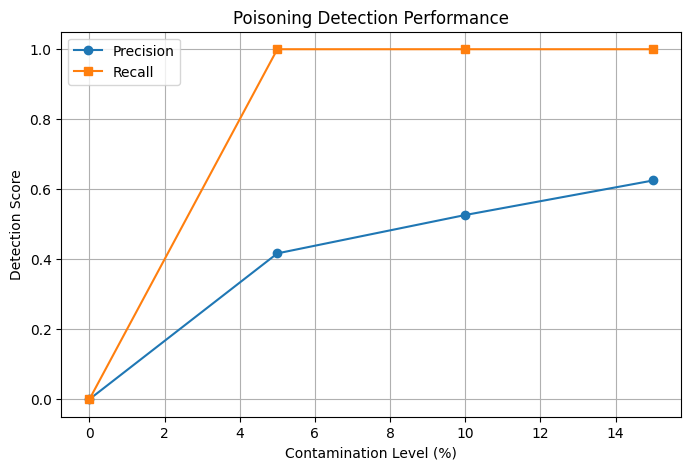

In [14]:
# Cell 14: Detection Performance

plt.figure(figsize=(8, 5))

plt.plot(
    detection_df["Contamination (%)"],
    detection_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    detection_df["Contamination (%)"],
    detection_df["Recall"],
    marker="s",
    label="Recall"
)

plt.xlabel("Contamination Level (%)")
plt.ylabel("Detection Score")
plt.title("Poisoning Detection Performance")

plt.grid(True)
plt.legend()

plt.show()

In [15]:
# Cell 15: Final Experiment Summary

final_results = results_df[
    [
        "Contamination",
        "Poisoned Records",
        "Accuracy",
        "F1 Score",
        "Accuracy Drop (%)",
        "F1 Drop (%)"
    ]
].copy()

display(final_results)

print("\nDetection Results")
print("=================")

display(detection_df)

,Contamination,Poisoned Records,Accuracy,F1 Score,Accuracy Drop (%),F1 Drop (%)
0,0.0,0,0.888889,0.887767,0.000000,0.000000
1,5.0,5,0.888889,0.885852,0.000000,0.191430
2,10.0,10,0.911111,0.909370,-2.222222,-2.160365
3,15.0,15,0.911111,0.909370,-2.222222,-2.160365



Detection Results


,Contamination (%),Known Poisoned,Detected Suspicious,True Positives,False Positives,False Negatives,Precision,Recall
0,0.0,0,2,0,2,0,0.000000,0.0
1,5.0,5,12,5,7,0,0.416667,1.0
2,10.0,10,19,10,9,0,0.526316,1.0
3,15.0,15,24,15,9,0,0.625000,1.0
